# 03 — Cohort Analysis (Customer Retention)

**Goal:** Group customers into monthly cohorts by their first purchase month, then track what fraction of each cohort keeps buying in subsequent months. 

Uses `outputs/data/cleaned_customer.csv` from `01_data_cleaning.ipynb`.

In [4]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv(r"D:\ProProjects\data-analytics-projects\ecom\outputs\data\cleaned_customer.csv", parse_dates=['invoicedate'])
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,iscancellation,totalprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


## 1. Assign each transaction to an order month and each customer to a cohort month 

- `OrderMonth` — the month a given transaction happened
- `CohortMonth` — the month of that customer's very first transaction (their acquisition month)

In [6]:
df['ordermonth'] = df['invoicedate'].dt.to_period('M')
cohort_month = df.groupby('customerid')['ordermonth'].transform('min')
df['cohortmonth'] = cohort_month

df[['customerid', 'invoicedate', 'ordermonth', 'cohortmonth']].head()

,customerid,invoicedate,ordermonth,cohortmonth
0,17850,2010-12-01 08:26:00,2010-12,2010-12
1,17850,2010-12-01 08:26:00,2010-12,2010-12
2,17850,2010-12-01 08:26:00,2010-12,2010-12
3,17850,2010-12-01 08:26:00,2010-12,2010-12
4,17850,2010-12-01 08:26:00,2010-12,2010-12


In [7]:
# Cohort index = how many months after acquisition this order happened (0 = acquisition month itself)

def period_diff(order_month, cohort_month):
    return (order_month.year - cohort_month.year) * 12 + (order_month.month - cohort_month.month)

df['cohortindex'] = df.apply(lambda r: period_diff(r['ordermonth'], r['cohortmonth']), axis=1)
df[['customerid', 'cohortmonth', 'ordermonth', 'cohortindex']].head()

,customerid,cohortmonth,ordermonth,cohortindex
0,17850,2010-12,2010-12,0
1,17850,2010-12,2010-12,0
2,17850,2010-12,2010-12,0
3,17850,2010-12,2010-12,0
4,17850,2010-12,2010-12,0


## 2. Build the retention matrix

Count distinct customers active in each (CohortMonth, CohortIndex) cell, then convert to a % of that cohort's original size.

In [8]:
cohort_data = df.groupby(['cohortmonth', 'cohortindex'])['customerid'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='cohortmonth', columns='cohortindex', values='customerid')

cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

retention.round(1)

cohortindex,0,1,2,3,4,5,6,7,8,9,10,11,12
cohortmonth,,,,,,,,,,,,,
2010-12,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


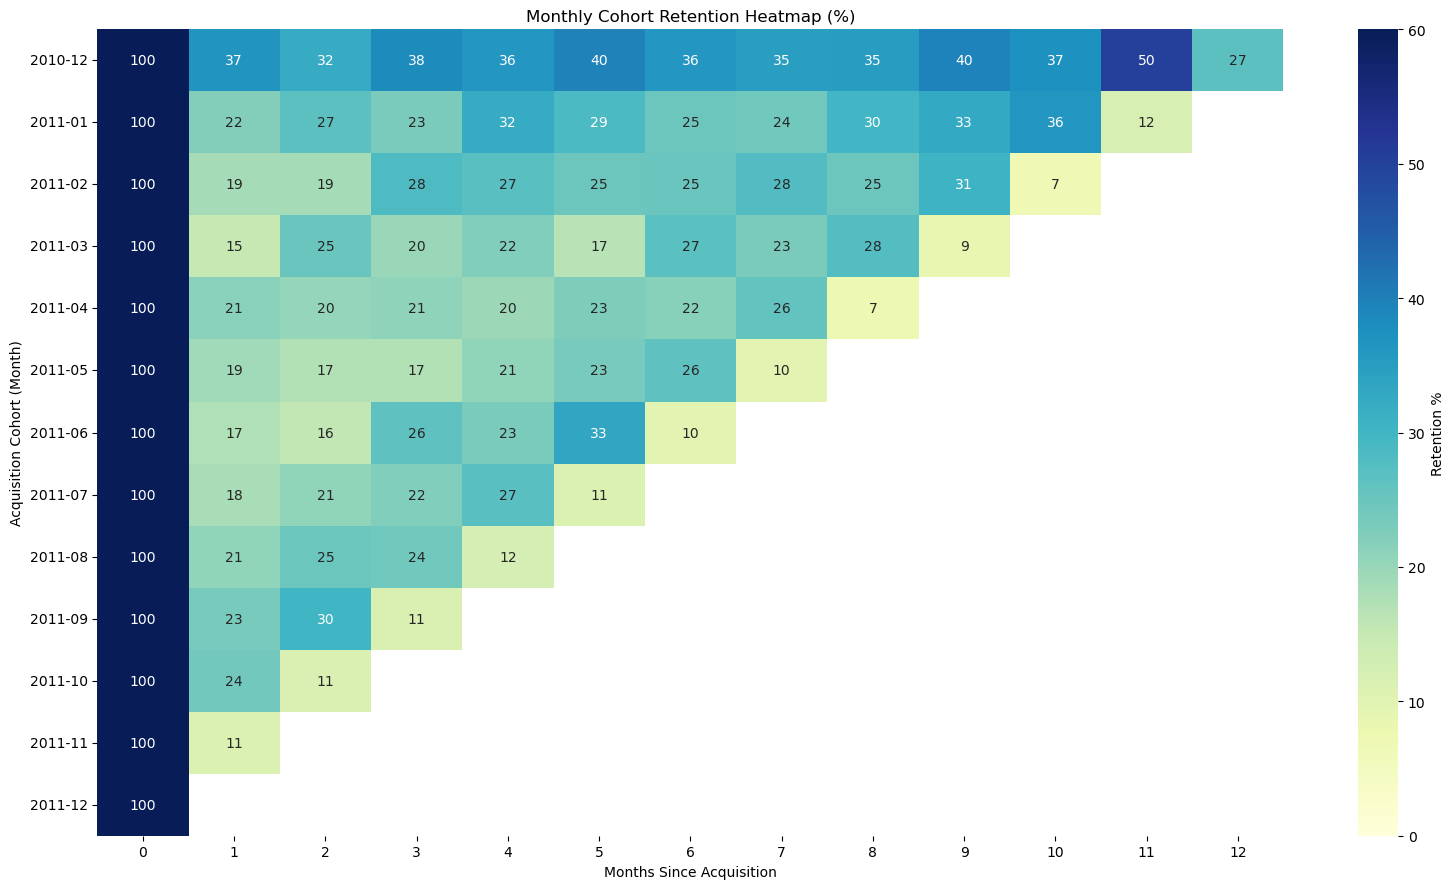

In [10]:
plt.figure(figsize=(16, 9))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='YlGnBu', vmin=0, vmax=60,
            cbar_kws={'label': 'Retention %'})
plt.title('Monthly Cohort Retention Heatmap (%)')
plt.xlabel('Months Since Acquisition')
plt.ylabel('Acquisition Cohort (Month)')
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', bbox_inches='tight')
plt.show()

## 3. Cohort sizes 

showing how many new customers were acquired each month?

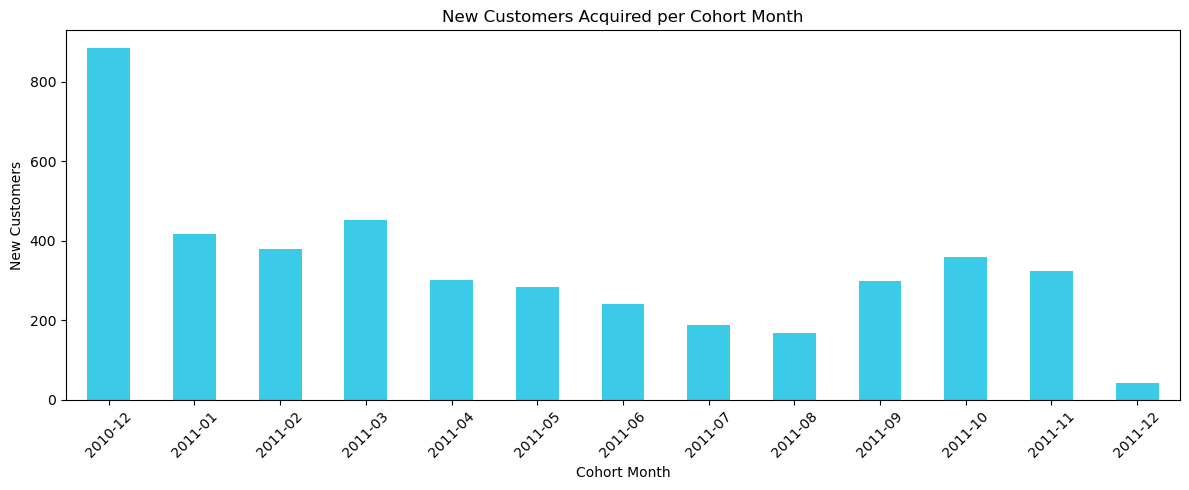

In [11]:
plt.figure(figsize=(12, 5))
cohort_sizes.plot(kind='bar', color='#3BCBE8')
plt.title('New Customers Acquired per Cohort Month')
plt.xlabel('Cohort Month')
plt.ylabel('New Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cohort_sizes.png', bbox_inches='tight')
plt.show()

## 4. Average Retention Curve

Calculate the average retention rate across mature cohorts, excluding the most recent

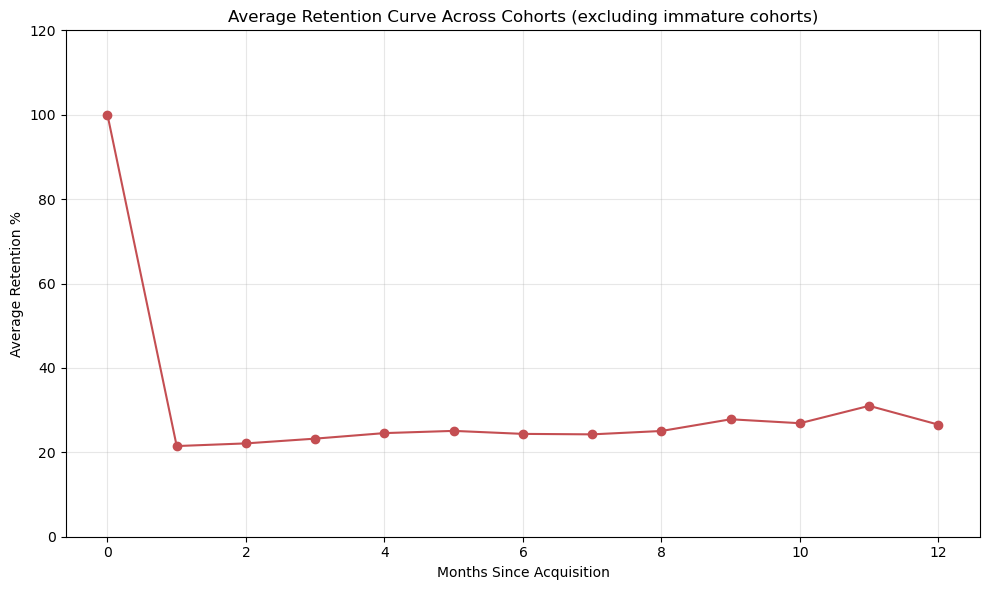

cohortindex
0     100.00
1      21.48
2      22.12
3      23.24
4      24.55
5      25.08
6      24.37
7      24.26
8      25.06
9      27.83
10     26.90
11     31.02
12     26.55
dtype: float64

In [13]:
# Exclude the last 2 cohort months since they haven't had time to show later-month retention
mature_cohorts = retention.iloc[:-2] if len(retention) > 2 else retention
avg_retention = mature_cohorts.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.plot(avg_retention.index, avg_retention.values, marker='o', color='#C44E52')
plt.title('Average Retention Curve Across Cohorts (excluding immature cohorts)')
plt.xlabel('Months Since Acquisition')
plt.ylabel('Average Retention %')
plt.ylim(0, avg_retention.max() * 1.2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_retention_curve.png', bbox_inches='tight')
plt.show()

avg_retention.round(2)